In [2]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras.layers import Dense , Activation,Flatten ,GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_crossentropy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import cv2

In [3]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

2026-03-14 11:00:30.403899: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-14 11:00:30.403944: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-14 11:00:30.403955: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-14 11:00:30.404068: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-14 11:00:30.404128: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
base_model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [5]:
x = base_model.output
x = Flatten()(x)              
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)          
predictions = Dense(4, activation='softmax')(x)

In [6]:
model =Model(inputs=base_model.input, outputs=predictions)

In [7]:
for layer in model.layers[:-15]:
    layer.trainable=False


In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [9]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [5]:
#function to split main data into train,val and test directory with defined ration
import os
import shutil
import random

def split_image_dataset(source_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
   
    if train_ratio + val_ratio + test_ratio != 1.0:
        print("Error: Ratios must sum to 1.0.")
        return

    # Create the top-level split folders
    base_dir = os.path.dirname(source_dir)
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')
    test_dir = os.path.join(base_dir, 'test')

    # Ensure clean directories by removing old ones first (optional but safe)
    for d in [train_dir, val_dir, test_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d)

    # Get the list of all subfolders (classes)
    class_names = [d for d in os.listdir(source_dir) 
                   if os.path.isdir(os.path.join(source_dir, d))]

    print(f"Found {len(class_names)} classes: {class_names}")

    # Process each class individually
    for class_name in class_names:
        class_path = os.path.join(source_dir, class_name)
        
        # Get all image file names in the class folder
        all_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))]
        
        # Randomly shuffle the files to ensure random selection for splits
        random.shuffle(all_files)
        
        total_files = len(all_files)
        
        # Calculate split indices
        train_end = int(train_ratio * total_files)
        val_end = train_end + int(val_ratio * total_files)

        train_files = all_files[:train_end]
        val_files = all_files[train_end:val_end]
        test_files = all_files[val_end:]
        
        # --- Copy Files to New Folders ---
        
        # 1. Create class subfolders in the new split directories
        for data_set_dir in [train_dir, val_dir, test_dir]:
            os.makedirs(os.path.join(data_set_dir, class_name), exist_ok=True)

        # 2. Define the lists of (destination directory, file list)
        split_plan = [
            (train_dir, train_files),
            (val_dir, val_files),
            (test_dir, test_files)
        ]

        # 3. Copy files
        for dest_base, files in split_plan:
            dest_path = os.path.join(dest_base, class_name)
            for file_name in files:
                source_file = os.path.join(class_path, file_name)
                # Using shutil.copy2 to preserve metadata (optional, can use shutil.copy)
                shutil.copy2(source_file, os.path.join(dest_path, file_name))
        
        print(f"Class **{class_name}** split: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

    print("\nDataset splitting complete!")

In [6]:
split_image_dataset('poultrydata')

Found 4 classes: ['cocci', 'ncd', 'healthy', 'salmo']
Class **cocci** split: Train=1682, Val=210, Test=211
Class **ncd** split: Train=300, Val=37, Test=39
Class **healthy** split: Train=1645, Val=205, Test=207
Class **salmo** split: Train=1820, Val=227, Test=229

Dataset splitting complete!


In [116]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", pred_index=None):
    """
    Generates a heat map for a specific image using the model's last conv layer.
    """
    # 1. Create a sub-model that maps: Input Image -> [Last Conv Layer Output, Final Predictions]
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        # If no specific class index is provided, use the one with the highest probability
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        
        # Get the "score" (probability) of the winning class
        class_channel = preds[:, pred_index]

    # 3. Calculate gradients of the class score with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Global Average Pooling of the gradients (get "importance weight" for each channel)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply feature map by importance weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU (keep only positive influence) & Normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def estimate_severity(heatmap, threshold=0.6):
    """
    Heuristic: Calculates severity based on how large the 'hot' area is.
    Returns: Severity Label ('Mild', 'Moderate', 'Severe') and Percentage Score
    """
    # Count pixels that are "hot" (above threshold)
    hot_pixels = np.sum(heatmap > threshold)
    total_pixels = heatmap.size
    
    # Calculate ratio (0.0 to 1.0)
    severity_ratio = hot_pixels / total_pixels
    
    # Assign Label
    if severity_ratio < 0.05:
        label = "Mild / Early Stage"
    elif severity_ratio < 0.10:
        label = "Moderate"
    else:
        label = "Severe"
        
    return label, severity_ratio * 100

def display_gradcam(img_path, heatmap, severity_label, severity_score):
    """
    Overlays the heatmap on the original image and displays it.
    """
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Fix color for Matplotlib
    
    # Resize heatmap to match original image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB (0-255)
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) # Fix color

    # Superimpose (0.4 is transparency intensity)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

    # Plot
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"{severity_label} ")
    plt.axis('off')
    
    plt.show()
def get_foreground_mask_largest_blob(img_path):
    # 1. Load image and convert to Grayscale
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 2. Blur to merge small details (helps find the whole shape)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 3. Basic Thresholding (Inverse often works better for poop on straw)
    # You might need to swap THRESH_BINARY_INV to THRESH_BINARY if background is dark
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 4. Find all contours (shapes)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Create an empty mask (all black)
    mask = np.zeros_like(gray)
    
    if contours:
        # 6. Find the largest contour by Area
        largest_contour = max(contours, key=cv2.contourArea)
        
        # 7. Draw ONLY that largest contour onto the mask as white (255)
        cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
        
    return mask

In [3]:
train_data=ImageDataGenerator(
    rotation_range=20,         
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True, 
    vertical_flip=True,
    zoom_range=0.2,
    preprocessing_function=preprocess_input
).flow_from_directory(
    directory='train',
    target_size=(224,224),batch_size=32
)
valid_data=ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    directory='val',
    target_size=(224,224),batch_size=32
)
test_data=ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    directory='test',
    target_size=(224,224),batch_size=32,
    shuffle=False,
)


Found 5447 images belonging to 4 classes.
Found 679 images belonging to 4 classes.
Found 686 images belonging to 4 classes.


In [12]:
model.fit(x=train_data,validation_data=valid_data,epochs=30,verbose =1)

Epoch 1/30


2026-03-14 11:01:18.208634: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


171/171 [==============================] - ETA: 0s - loss: 3.2687 - accuracy: 0.8652

2026-03-14 11:05:04.689070: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


171/171 [==============================] - 252s 1s/step - loss: 3.2687 - accuracy: 0.8652 - val_loss: 1.1530 - val_accuracy: 0.9396
Epoch 2/30
171/171 [==============================] - 246s 1s/step - loss: 0.8994 - accuracy: 0.9389 - val_loss: 0.6472 - val_accuracy: 0.9602
Epoch 3/30
171/171 [==============================] - 244s 1s/step - loss: 0.4990 - accuracy: 0.9559 - val_loss: 0.3440 - val_accuracy: 0.9735
Epoch 4/30
171/171 [==============================] - 246s 1s/step - loss: 0.4032 - accuracy: 0.9662 - val_loss: 0.3921 - val_accuracy: 0.9720
Epoch 5/30
171/171 [==============================] - 246s 1s/step - loss: 0.3145 - accuracy: 0.9682 - val_loss: 0.3064 - val_accuracy: 0.9750
Epoch 6/30
171/171 [==============================] - 247s 1s/step - loss: 0.2085 - accuracy: 0.9748 - val_loss: 0.3084 - val_accuracy: 0.9735
Epoch 7/30
171/171 [==============================] - 247s 1s/step - loss: 0.2044 - accuracy: 0.9739 - val_loss: 0.3554 - val_accuracy: 0.9735
Epoch 8/30

In [13]:
result = model.evaluate(test_data , verbose=1)

22/22 [==============================] - 25s 1s/step - loss: 0.8368 - accuracy: 0.9679


In [14]:
print('loss = ',result[0])
print('accuracy = ',result[1])

loss =  0.8367533087730408
accuracy =  0.967930018901825


NameError: name 'model' is not defined

In [35]:
#setting index number which ppoint out to index'th image of the first batch in test data should be <31
index=3
#batch number should be <=22 as there are 22 batches in test_data
batch_number=0


#extracting batch_number'th batch of the test data
first_batch=salmo_test[batch_number]
#extracting image batch of the first batch
first_image_batch=first_batch[0]
#extracing lebel batch of the first batch
first_label_batch=first_batch[1]
#extracting index of the label of the first image
label_index=np.argmax(first_label_batch[index])
#extracting first image and expanding its dimentions from 3 to 4
first_image=first_image_batch[index]
first_image_exp_dim=np.expand_dims(first_image_batch[index],axis=0)
#creating key value pair with key as label index and value as label name i.e 1:'cocci'
idx_to_class = {v: k for k, v in test_data.class_indices.items()}






In [36]:
#raw predinction of the first image
raw_prediction = model.predict(first_image_exp_dim)

1/1 [==============================] - 0s 49ms/step


acutal label : salmo
predicted label: salmo


array([[0., 0., 0., 1.]], dtype=float32)

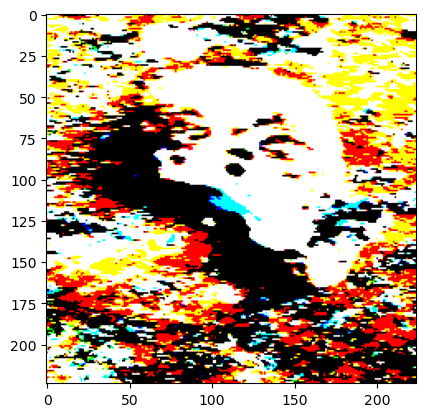

In [37]:
image_prediction_index=np.argmax(raw_prediction[0])
actual_label=idx_to_class[label_index]
predicted_label=idx_to_class[image_prediction_index]
print('acutal label :',actual_label)
print('predicted label:',predicted_label)
plt.imshow(first_image)
raw_prediction

Predicted Severity: Severe (12.24% infection spread)


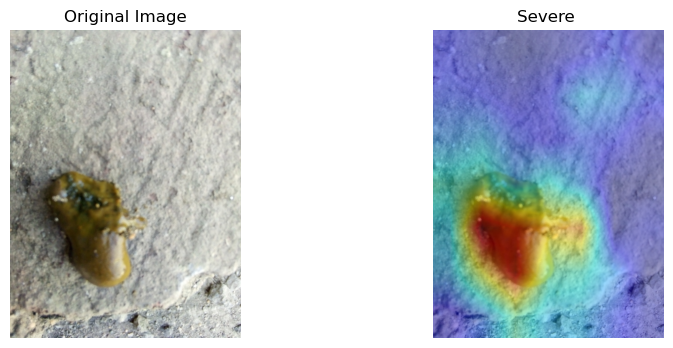

In [118]:
# --- STEP 1: PREPARE IMAGE FOR MODEL (Standard) ---
img_path = 'test/cocci/cocci.278.jpg'
# 2. Preprocess it exactly like your model expects
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
preprocessed_img = preprocess_input(img_batch) # ResNet50 specific preprocessing

# 3. Generate Heatmap
# Note: 'model' is your trained ResNet50 model
heatmap = make_gradcam_heatmap(preprocessed_img,model, last_conv_layer_name="conv5_block3_out")

# 4. Calculate Severity
label, score = estimate_severity(heatmap, threshold=0.5)

# 5. Show Result
print(f"Predicted Severity: {label} ({score:.2f}% infection spread)")
display_gradcam(img_path, heatmap, label, score)

In [15]:
model.save("saved_model_resnet_30epochs")

INFO:tensorflow:Assets written to: saved_model_resnet_30epochs/assets


INFO:tensorflow:Assets written to: saved_model_resnet_30epochs/assets


In [16]:
test_labels=test_data.classes
predictions=model.predict(x=test_data , verbose=0)
cm = confusion_matrix(y_true=test_labels, y_pred=predictions.argmax(axis=1))

2026-03-14 15:27:35.499676: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


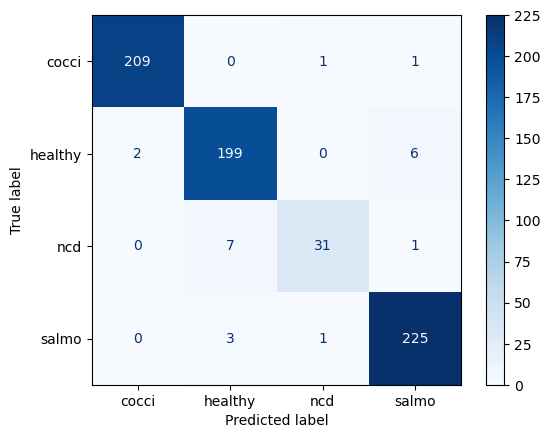

In [17]:
ypred = ["cocci","healthy","ncd","salmo"]
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ypred)
disp.plot(cmap=plt.cm.Blues)
    